In [1]:
import numpy as np
import pandas as pd
import itertools
import json
from pathlib import Path
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, recall_score,classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN
import os
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import gc

In [2]:
X = pd.read_pickle("Sets_Xy/X.pkl")
y = pd.read_pickle("Sets_Xy/y.pkl")

from sklearn.model_selection import train_test_split

#Division estratificada para muestras de cada clase a nivel de cada subset

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, 
    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, 
    random_state=42)

#Encoding de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapeo_labels = pd.DataFrame({
    "label_original": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels)
class_names = le.classes_

Mapeo de etiquetas:
                label_original  label_encoded
0                      BENIGN              0
1                         Bot              1
2                        DDoS              2
3               DoS GoldenEye              3
4                    DoS Hulk              4
5            DoS Slowhttptest              5
6               DoS slowloris              6
7                 FTP-Patator              7
8                  Heartbleed              8
9                Infiltration              9
10                   PortScan             10
11                SSH-Patator             11
12    Web Attack  Brute Force             12
13  Web Attack  Sql Injection             13
14            Web Attack  XSS             14


In [8]:
import joblib

X_train_none = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_none = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

X_val = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
y_val = pd.DataFrame(y_val)

X_test = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
y_test = pd.DataFrame(y_test)

y_val_1d = y_val.values.ravel() if isinstance(y_val, pd.DataFrame) else y_val.ravel()
y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test.ravel()


Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


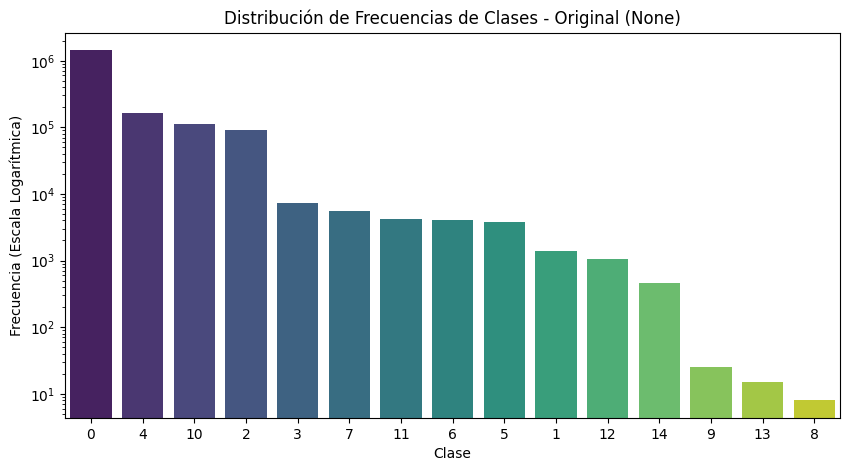

In [9]:
def analizar_distribuciones(y, nombre_dataset=""):
    total_muestras = len(y)
    classes, counts = np.unique(y, return_counts=True)
    
    sorted_idx = np.argsort(counts)[::-1]
    classes = classes[sorted_idx]
    counts = counts[sorted_idx]
    
    majority_count = counts[0]
    minority_count = counts[-1]
    imbalance_ratio = majority_count / minority_count
    
    print(f"Analisis de Distribucion: {nombre_dataset.upper()}")
    print(f"Total de muestras: {total_muestras:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1\n")
    
    porcentajes = (counts / total_muestras) * 100
    df_dist = pd.DataFrame({
        'Clase': classes,
        'Conteo': counts,
        'Porcentaje (%)': porcentajes
    })
    
    df_dist['Porcentaje (%)'] = df_dist['Porcentaje (%)'].map('{:.4f}%'.format)
    
    print(df_dist.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[str(c) for c in classes], y=counts, palette="viridis", hue=[str(c) for c in classes], legend=False)
    plt.title(f"Distribución de Frecuencias de Clases - {nombre_dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia (Escala Logarítmica)")
    plt.yscale('log')
    plt.show()
    
    return classes, counts

classes, counts = analizar_distribuciones(y_train_none, "Original (None)")

In [20]:
import numpy as np
import pandas as pd
import joblib
import os
from collections import Counter
from sklearn.model_selection import train_test_split

X_train_base = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_base = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

if isinstance(y_train_base, pd.DataFrame) or isinstance(y_train_base, pd.Series):
    y_train_base = y_train_base.values.ravel()

CLASE_BENIGNA = 0
clases_experto_1 = [0]                
clases_experto_2 = [2, 4, 10]         
clases_experto_3 = [3, 5, 6, 7, 11]   
clases_experto_4 = [1]                
clases_experto_5 = [12, 13, 14]       
clases_experto_6 = [8, 9]             

os.makedirs("Sets_Expertos_MoE", exist_ok=True)

def predecir_tamano_post_smote(y_objetivo, target_large=200000):
    counts = Counter(y_objetivo)
    total_futuro = 0
    
    for cls, cnt in counts.items():
        if cls == CLASE_BENIGNA:
            total_futuro += cnt
        elif cnt < 100:
            total_futuro += 2500
        elif cnt < 1000:
            total_futuro += 10000
        elif cnt < 5000:
            total_futuro += 25000
        elif cnt < 20000:
            total_futuro += 50000
        else:
            total_futuro += max(cnt, target_large)
            
    return total_futuro

def generar_subset_experto_exacto(X, y, clases_objetivo, clase_benigna=0, nombre_experto="Experto"):
    mask_objetivo = np.isin(y, clases_objetivo)
    X_objetivo = X[mask_objetivo]
    y_objetivo = y[mask_objetivo]
    
    mask_ruido = ~np.isin(y, clases_objetivo)
    X_ruido_pool = X[mask_ruido]
    y_ruido_pool = y[mask_ruido]
    
    tamano_objetivo_futuro = predecir_tamano_post_smote(y_objetivo)
    
    n_ruido = int(tamano_objetivo_futuro / 9)
    
    n_ruido = min(n_ruido, len(y_ruido_pool))
    
    if n_ruido > 0:
        X_ruido_sample, _, y_ruido_sample, _ = train_test_split(
            X_ruido_pool, y_ruido_pool, 
            train_size=n_ruido, 
            stratify=y_ruido_pool, 
            random_state=42
        )
        
        if hasattr(X, 'iloc'):
            X_final = pd.concat([X_objetivo, X_ruido_sample], axis=0)
        else:
            X_final = np.vstack((X_objetivo, X_ruido_sample))
        y_final = np.concatenate([y_objetivo, y_ruido_sample])
    else:
        X_final = X_objetivo
        y_final = y_objetivo

    joblib.dump(X_final, f"Sets_Expertos_MoE/X_train_{nombre_experto}.joblib")
    joblib.dump(y_final, f"Sets_Expertos_MoE/y_train_{nombre_experto}.joblib")
    
    print(f"{nombre_experto.upper()}")
    muestras_objetivo_actual = len(y_objetivo)
    muestras_ruido_actual = len(y_final) - muestras_objetivo_actual
    
    print(f"Estado Antes de SMOTE:")
    print(f"  Objetivo: {muestras_objetivo_actual:,} | Ruido inyectado: {muestras_ruido_actual:,}")
    
    total_futuro = tamano_objetivo_futuro + n_ruido
    pct_obj = (tamano_objetivo_futuro / total_futuro) * 100
    pct_ruido = (n_ruido / total_futuro) * 100
    
    print(f"Estado Post-SMOTE:")
    print(f"  Objetivo: {tamano_objetivo_futuro:,} ({pct_obj:.2f}%) | Ruido: {n_ruido:,} ({pct_ruido:.2f}%)\n")
    
    return X_final, y_final

print("Generando subsets para entrenamiento de expertos de Mixture of Experts...\n")

X_e1, y_e1 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_1, nombre_experto="E1_Benigno")
X_e2, y_e2 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_2, nombre_experto="E2_Mayoritarios")
X_e3, y_e3 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_3, nombre_experto="E3_Medios")
X_e4, y_e4 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_4, nombre_experto="E4_Bot")
X_e5, y_e5 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_5, nombre_experto="E5_WebAttacks")
X_e6, y_e6 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_6, nombre_experto="E6_Minoritarios")

Generando subsets para entrenamiento de expertos de Mixture of Experts...

E1_BENIGNO
Estado Antes de SMOTE:
  Objetivo: 1,433,001 | Ruido inyectado: 159,222
Estado Post-SMOTE:
  Objetivo: 1,433,001 (90.00%) | Ruido: 159,222 (10.00%)

E2_MAYORITARIOS
Estado Antes de SMOTE:
  Objetivo: 362,621 | Ruido inyectado: 66,666
Estado Post-SMOTE:
  Objetivo: 600,000 (90.00%) | Ruido: 66,666 (10.00%)

E3_MEDIOS
Estado Antes de SMOTE:
  Objetivo: 24,796 | Ruido inyectado: 19,444
Estado Post-SMOTE:
  Objetivo: 175,000 (90.00%) | Ruido: 19,444 (10.00%)

E4_BOT
Estado Antes de SMOTE:
  Objetivo: 1,376 | Ruido inyectado: 2,777
Estado Post-SMOTE:
  Objetivo: 25,000 (90.00%) | Ruido: 2,777 (10.00%)

E5_WEBATTACKS
Estado Antes de SMOTE:
  Objetivo: 1,526 | Ruido inyectado: 4,166
Estado Post-SMOTE:
  Objetivo: 37,500 (90.00%) | Ruido: 4,166 (10.00%)

E6_MINORITARIOS
Estado Antes de SMOTE:
  Objetivo: 33 | Ruido inyectado: 555
Estado Post-SMOTE:
  Objetivo: 5,000 (90.01%) | Ruido: 555 (9.99%)



In [25]:
from collections import Counter

#Diccionario para obtener mas muestras en clases sumamente minoritarias para mejorar su clasificacion
def get_ids_proportions(y, clases_experto, target_large=200000):
    counts = Counter(y)
    majority_count = max(counts.values())
    proportion_dict = {}

    for cls, cnt in counts.items():
        if cls in clases_experto:
            if cnt == majority_count:
                proportion_dict[cls] = cnt
                continue
                
            elif cnt < 100:
                proportion_dict[cls] = 2500
                
            elif cnt < 1000:
                proportion_dict[cls] = 10000
                
            elif cnt < 5000:
                proportion_dict[cls] = 25000 
                
            elif cnt < 20000:
                proportion_dict[cls] = 50000
                
            else:
                proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [29]:
import joblib

proportion_dict_E2 = get_ids_proportions(y_train_base, clases_experto_2)
proportion_dict_E3 = get_ids_proportions(y_train_base, clases_experto_3)
proportion_dict_E4 = get_ids_proportions(y_train_base, clases_experto_4)
proportion_dict_E5 = get_ids_proportions(y_train_base, clases_experto_5)
proportion_dict_E6 = get_ids_proportions(y_train_base, clases_experto_6)

print("Diccionarios por sets para los expertos")
print(f"E2: {proportion_dict_E2}")
print(f"E3: {proportion_dict_E3}")
print(f"E4: {proportion_dict_E4}")
print(f"E5: {proportion_dict_E5}")
print(f"E6: {proportion_dict_E6}")

Diccionarios por sets para los expertos
E2: {np.int64(4): 200000, np.int64(2): 200000, np.int64(10): 200000}
E3: {np.int64(11): 25000, np.int64(3): 50000, np.int64(7): 50000, np.int64(6): 25000, np.int64(5): 25000}
E4: {np.int64(1): 25000}
E5: {np.int64(12): 25000, np.int64(14): 10000, np.int64(13): 2500}
E6: {np.int64(9): 2500, np.int64(8): 2500}


In [30]:
class OversamplingWithArtifactAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, method='smote', proportion=None, random_state=42, n_neighbors=5, **kwargs):
        self.method = method
        self.proportion = proportion
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.kwargs = kwargs
        
        self.oversampler_ = None
        self.artifacts_report_ = {}

    def fit(self, X, y=None):
        if self.method == 'none':
            return self

        if self.method == 'smote':
            self.oversampler_ = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
        elif self.method == 'smote_tomek':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTETomek(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        elif self.method == 'smote_enn':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTEENN(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        
        return self

    def fit_resample(self, X, y):
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
        orig_counts = Counter(y)

        if self.method == 'none':
            self._generar_reporte_avanzado(X, y, X, y, orig_counts, orig_counts)
            return X, y

        self.fit(X, y)
        
        X_res, y_res = self.oversampler_.fit_resample(X, y)
        new_counts = Counter(y_res)
        
        self._generar_reporte_avanzado(X, y, X_res, y_res, orig_counts, new_counts)

        if feature_names:
            X_res = pd.DataFrame(X_res, columns=feature_names)
            
        return X_res, y_res

    def _generar_reporte_avanzado(self, X_orig, y_orig, X_res, y_res, orig_counts, new_counts):
        if hasattr(X_orig, 'values'): X_orig = X_orig.values
        if hasattr(y_orig, 'values'): y_orig = y_orig.values
        if hasattr(X_res, 'values'): X_res = X_res.values
        if hasattr(y_res, 'values'): y_res = y_res.values

        reporte = {
            'metodo': self.method,
            'proporcion_config': {str(k): int(v) for k, v in self.proportion.items()} if isinstance(self.proportion, dict) else self.proportion,
            'resumen': {
                'muestras_antes': int(sum(orig_counts.values())),
                'muestras_despues': int(sum(new_counts.values())),
                'incremento_total': int(sum(new_counts.values()) - sum(orig_counts.values()))
            },
            'distribucion_original': {str(k): int(v) for k, v in orig_counts.items()},
            'distribucion_final': {str(k): int(v) for k, v in new_counts.items()},
            'analisis_por_clase': {}
        }

        unique_classes = np.unique(y_orig)
        print(f"\nCalculando métricas de artefactos para: {self.method.upper()}...")

        n_orig_total = len(X_orig)
        if self.method == 'smote':
            X_synth_global = X_res[n_orig_total:]
            y_synth_global = y_res[n_orig_total:]

        for clase in unique_classes:
            clase_str = str(clase)
            c_orig = orig_counts.get(clase, 0)
            c_new = new_counts.get(clase, 0)

            X_orig_c = X_orig[y_orig == clase]
            
            if self.method == 'smote':
                X_synth_c = X_synth_global[y_synth_global == clase]
            else:
                X_res_c = X_res[y_res == clase]
                if len(X_orig_c) > 0 and len(X_res_c) > 0:
                    nn_filter = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(X_orig_c)
                    dists, _ = nn_filter.kneighbors(X_res_c)
                    X_synth_c = X_res_c[dists.flatten() > 1e-6]
                else:
                    X_synth_c = np.array([])

            if c_new > c_orig: estado = "Oversampled"
            elif c_new < c_orig: estado = "Undersampled / Limpiado"
            else: estado = "Intacto"

            clase_info = {
                "estado": estado,
                "originales": int(c_orig),
                "finales": int(c_new),
                "sinteticas_puras_detectadas": int(len(X_synth_c)),
                "multiplicador": float(round(c_new / c_orig, 2)) if c_orig > 0 else 0.0
            }

            if len(X_orig_c) > 1 and len(X_synth_c) > 0 and estado != "Intacto":
                
                #Distancia interna original
                nn_baseline = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
                nn_baseline.fit(X_orig_c)
                dist_base, _ = nn_baseline.kneighbors(X_orig_c)
                mean_dist_base = float(np.mean(dist_base[:, 1]))

                #Distancia total de los datos nuevos hacia los originales
                nn_post = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
                nn_post.fit(X_orig_c)
                dist_post, _ = nn_post.kneighbors(X_synth_c)
                mean_dist_post = float(np.mean(dist_post))
                
                #Detectar duplicados exactos
                duplicados_pct = float(np.sum(dist_post < 1e-8) / len(dist_post) * 100)

                #Evaluación de Riesgo de Artefactos
                riesgo = "Bajo (Consistente)"
                if duplicados_pct > 5.0:
                    riesgo = f"Alto (Alerta de Duplicidad: {round(duplicados_pct, 1)}%)"
                elif mean_dist_base > 0 and (mean_dist_post > mean_dist_base * 2.5):
                    riesgo = "Alto (Artefactos Lejanos / Ruido)"

                clase_info["metricas_vecindario"] = {
                    "distancia_media_interna_original": float(round(mean_dist_base, 6)),
                    "distancia_media_sinteticos_a_originales": float(round(mean_dist_post, 6)),
                    "porcentaje_duplicados_exactos": float(round(duplicados_pct, 2)),
                    "riesgo_artefactos": riesgo
                }

            reporte['analisis_por_clase'][clase_str] = clase_info

        self.artifacts_report_ = reporte
        
        print(f"Análisis completado. Muestras: {reporte['resumen']['muestras_antes']} -> {reporte['resumen']['muestras_despues']}")
        
        for k, v in reporte['analisis_por_clase'].items():
            if 'metricas_vecindario' in v and "Alto" in v['metricas_vecindario']['riesgo_artefactos']:
                print(f"Precaución Clase {k}: {v['metricas_vecindario']['riesgo_artefactos']}")

    def transform(self, X):
        return X

    def get_artifacts_report(self):
        return self.artifacts_report_

    def save_report(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.artifacts_report_, f, indent=2, default=str)

In [ ]:
X_train_E2 = joblib.load("Sets_Expertos_MoE/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load("Sets_Expertos_MoE/y_train_E2_Mayoritarios.joblib").astype(np.float32)
X_train_E3 = joblib.load("Sets_Expertos_MoE/X_train_E3_Medios.joblib").astype(np.float32)
y_train_E3 = joblib.load("Sets_Expertos_MoE/y_train_E3_Medios.joblib").astype(np.float32)
X_train_E4 = joblib.load("Sets_Expertos_MoE/X_train_E4_Bot.joblib").astype(np.float32)
y_train_E4 = joblib.load("Sets_Expertos_MoE/y_train_E4_Bot.joblib").astype(np.float32)
X_train_E5 = joblib.load("Sets_Expertos_MoE/X_train_E5_WebAttacks.joblib").astype(np.float32)
y_train_E5 = joblib.load("Sets_Expertos_MoE/y_train_E5_WebAttacks.joblib").astype(np.float32)
X_train_E6 = joblib.load("Sets_Expertos_MoE/X_train_E6_Minoritarios.joblib").astype(np.float32)
y_train_E6 = joblib.load("Sets_Expertos_MoE/y_train_E6_Minoritarios.joblib").astype(np.float32)

classes, counts = analizar_distribuciones(y_train_E2, "Set-E2-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E3, "Set-E3-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E4, "Set-E4-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E5, "Set-E5-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E6, "Set-E6-Previo SMOTE")

In [ ]:
sets_moe= [[X_train_E2, y_train_E2, proportion_dict_E2],[X_train_E3, y_train_E3, proportion_dict_E3],[X_train_E4, y_train_E4, proportion_dict_E4],[X_train_E5, y_train_E5, proportion_dict_E5],[X_train_E2, y_train_E6, proportion_dict_E6]]
props_dicts_moe=[proportion_dict_E2,proportion_dict_E3,proportion_dict_E4,proportion_dict_E5,proportion_dict_E6]
oversampling_methods = ['none', 'smote', 'smote_enn', 'smote_tomek']
import gc

for i in range (len(sets_moe)):

    for over_method in oversampling_methods:
        print(f"\nIniciando método: {over_method.upper()} para set de experto {i+2}")
        
        X_train_input=sets_moe[i][0]
        y_train_input=sets_moe[i][1]

        if over_method == 'none':
            X_train_over, y_train_over = X_train_input, y_train_input
            joblib.dump(X_train_over, f"Sets_Oversampling_MoE/X_train_{over_method}_Experto_{i+2}.joblib")
            joblib.dump(y_train_over, f"Sets_Oversampling_MoE/y_train_{over_method}_Experto_{i+2}.joblib")
            print("Finalizado: Datos originales mantenidos.")
            continue
            
        oversampler = OversamplingWithArtifactAnalysis(
            method=over_method,
            proportion=props_dicts_moe[i],
            random_state=42,
            n_neighbors=5
        )
        
        try:
            X_train_over, y_train_over = oversampler.fit_resample(X_train_input, y_train_input)
            joblib.dump(X_train_over, f"Sets_Oversampling_MoE/X_train_{over_method}_Experto_{i+2}.joblib")
            joblib.dump(y_train_over, f"Sets_Oversampling_MoE/y_train_{over_method}_Experto_{i+2}.joblib")
            oversampler.save_report(f"artifacts_{over_method}_MoE_Experto_{i+2}.json")
            print(f"Finalizado con éxito. Nuevo tamaño: {len(y_train_over)}")
            
        except ValueError as e:
            print(f"Advertencia: {over_method.upper()} falló en la interpolación.")
            print(f"Error reportado: {e}")
            print("Continuando con el siguiente método de la lista")
        
        del oversampler
        gc.collect()
